In [ ]:
# 1. Import libraries


import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Machine Learning Imports

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Set a simple chart style
sns.set_style("whitegrid")

print("Libraries imported successfully!")


In [2]:
# 2. Load Excel file

# Change this path if your Excel file is in another location
file_path = r"C:\Users\YASHANTU AWANA\OneDrive\Desktop\Major\master_dataset.xlsx"

# Read the Excel file
student_df = pd.read_excel(file_path)

print("Data loaded successfully!")
print("Dataset Shape:", student_df.shape)

# Show the first 5 rows
student_df.head()



Data loaded successfully!
Dataset Shape: (1400, 20)


,Student Name,Course,Academic Year,Semester,Section,Roll No,Enrollment No,Mentor,Attendance,Fees Paid,Fees Due,Total Fees,Mid Term,End Term,Assignment,Practical,Total Marks,Grade,Class Performance,Remarks
0,Aadi Oberoi,BSc Data Science,2024-25,I,A,BScDS01001,ENBScDS20250001,Nitish Patil,82.5,0,50000,50000,21.1,27.3,6.4,11.0,59.8,B,Excellent,Regular
1,Akash Kumar,BSc Data Science,2024-25,I,A,BScDS01002,ENBScDS20250002,Nitish Patil,80.4,0,50000,50000,10.4,26.6,10.1,10.3,52.2,B,Good,Regular
2,Anubhav Rai,BSc Data Science,2024-25,I,A,BScDS01003,ENBScDS20250003,Nitish Patil,85.8,50000,0,50000,18.2,26.6,10.9,18.1,67.1,B+,Excellent,Regular
3,Ayushi Singh,BSc Data Science,2024-25,I,A,BScDS01004,ENBScDS20250004,Nitish Patil,87.6,5000,45000,50000,20.5,30.2,6.6,19.6,69.9,B+,Average,Regular
4,Barun Yadav,BSc Data Science,2024-25,I,A,BScDS01005,ENBScDS20250005,Nitish Patil,59.4,15000,35000,50000,11.5,45.4,11.0,18.1,78.2,A,Needs Improvement,Low Attendance


In [3]:
# Show the last 5 rows
student_df.tail()

,Student Name,Course,Academic Year,Semester,Section,Roll No,Enrollment No,Mentor,Attendance,Fees Paid,Fees Due,Total Fees,Mid Term,End Term,Assignment,Practical,Total Marks,Grade,Class Performance,Remarks
1395,Anup Nair,Diploma in DS & AI,2024-25,II,C,DIP2502031,ENDIP20240031,Gaurav Kumar,61.0,50000,0,50000,16.3,39.8,6.3,12.0,67.6,B+,Excellent,Low Attendance
1396,Tarun Mishra,Diploma in DS & AI,2024-25,II,C,DIP2502032,ENDIP20240032,Gaurav Kumar,69.9,5000,45000,50000,10.0,41.3,6.7,15.5,66.8,B+,Good,Low Attendance
1397,Shlok Bagri,Diploma in DS & AI,2024-25,II,C,DIP2502033,ENDIP20240033,Gaurav Kumar,78.6,10000,40000,50000,15.8,20.6,10.4,12.8,54.2,B,Good,Regular
1398,Drishti Shah,Diploma in DS & AI,2024-25,II,C,DIP2502034,ENDIP20240034,Gaurav Kumar,88.7,0,50000,50000,18.3,34.0,9.9,18.2,73.1,A,Needs Improvement,Regular
1399,Pallavi Tiwari,Diploma in DS & AI,2024-25,II,C,DIP2502035,ENDIP20240035,Gaurav Kumar,73.4,5000,45000,50000,17.8,29.8,7.6,14.7,63.5,B+,Good,Low Attendance


In [4]:
# 3. Explore the dataset

print("Column Names:")
print(student_df.columns.tolist())

print("\nDataset Information:")
student_df.info()

print("\nMissing Values:")
print(student_df.isnull().sum())

print("\nDuplicate Rows:", student_df.duplicated().sum())


Column Names:
['Student Name', 'Course', 'Academic Year', 'Semester', 'Section', 'Roll No', 'Enrollment No', 'Mentor', 'Attendance', 'Fees Paid', 'Fees Due', 'Total Fees', 'Mid Term', 'End Term', 'Assignment', 'Practical', 'Total Marks', 'Grade', 'Class Performance', 'Remarks']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student Name       1400 non-null   object 
 1   Course             1400 non-null   object 
 2   Academic Year      1400 non-null   object 
 3   Semester           1400 non-null   object 
 4   Section            1400 non-null   object 
 5   Roll No            1400 non-null   object 
 6   Enrollment No      1400 non-null   object 
 7   Mentor             1400 non-null   object 
 8   Attendance         1400 non-null   float64
 9   Fees Paid          1400 non-null   int64  
 10  Fees Due   

In [5]:
# 4. Clean column names

# Remove extra spaces from column names
student_df.columns = student_df.columns.str.strip()

print("Cleaned column names:")
print(student_df.columns.tolist())


Cleaned column names:
['Student Name', 'Course', 'Academic Year', 'Semester', 'Section', 'Roll No', 'Enrollment No', 'Mentor', 'Attendance', 'Fees Paid', 'Fees Due', 'Total Fees', 'Mid Term', 'End Term', 'Assignment', 'Practical', 'Total Marks', 'Grade', 'Class Performance', 'Remarks']


In [6]:
# 5. Convert important columns to numbers

# These are the columns we normally use for calculations.
# The code only converts a column if it exists in the dataset.

numeric_columns = [
    "Attendance (%)",
    "Attendance",
    "Fees Paid ($)",
    "Fees Paid",
    "Fees Due ($)",
    "Fees Due",
    "Total Fees ($)",
    "Total Fees",
    "Mid-Term Marks",
    "Mid Term",
    "End-Term Marks",
    "End Term",
    "Assignment Marks",
    "Assignment",
    "Practical Marks",
    "Practical",
    "Total Marks (%)",
    "Total Marks"
]

for column in numeric_columns:
    if column in student_df.columns:
        student_df[column] = pd.to_numeric(
            student_df[column],
            errors="coerce"
        )

print("Numeric columns checked and converted.")


Numeric columns checked and converted.


In [7]:
# 6. Create simple helper columns

# Use the correct marks column from the dataset
marks_column = None

for column in ["Total Marks (%)", "Total Marks"]:
    if column in student_df.columns:
        marks_column = column
        break

# Use the correct attendance column
attendance_column = None

for column in ["Attendance (%)", "Attendance"]:
    if column in student_df.columns:
        attendance_column = column
        break

print("Marks column:", marks_column)
print("Attendance column:", attendance_column)


Marks column: Total Marks
Attendance column: Attendance


In [8]:
# 7. Create Pass/Fail column

if marks_column is not None:
    student_df["Pass_Fail"] = np.where(
        student_df[marks_column] >= 50,
        "Pass",
        "Fail"
    )

    print(student_df[[marks_column, "Pass_Fail"]].head())
else:
    print("Marks column was not found.")


   Total Marks Pass_Fail
0         59.8      Pass
1         52.2      Pass
2         67.1      Pass
3         69.9      Pass
4         78.2      Pass


In [9]:
# 8. Create Low Attendance column

if attendance_column is not None:
    student_df["Low_Attendance"] = np.where(
        student_df[attendance_column] < 75,
        1,
        0
    )

    print(student_df[[attendance_column, "Low_Attendance"]].head())
else:
    print("Attendance column was not found.")


   Attendance  Low_Attendance
0        82.5               0
1        80.4               0
2        85.8               0
3        87.6               0
4        59.4               1


In [10]:
# 9. Create At-Risk column

# A student is At-Risk if:
# - Attendance is below 75%, OR
# - Marks are below 50%

if attendance_column is not None and marks_column is not None:
    student_df["At_Risk"] = np.where(
        (student_df[attendance_column] < 75) |
        (student_df[marks_column] < 50),
        1,
        0
    )

    print(student_df[["At_Risk"]].head())
else:
    print("Attendance or marks column was not found.")


   At_Risk
0        0
1        0
2        0
3        0
4        1


In [11]:
# 10. Basic student statistics

print("===== STUDENT STATISTICS =====")

print("Total Records:", len(student_df))

if "Student Name" in student_df.columns:
    print("Unique Students:", student_df["Student Name"].nunique())

if "Course" in student_df.columns:
    print("Total Courses:", student_df["Course"].nunique())

if "Academic Year" in student_df.columns:
    print("Academic Years:", student_df["Academic Year"].nunique())

if attendance_column is not None:
    print(
        "Average Attendance:",
        round(student_df[attendance_column].mean(), 2),
        "%"
    )

if marks_column is not None:
    print(
        "Average Marks:",
        round(student_df[marks_column].mean(), 2),
        "%"
    )

if "Pass_Fail" in student_df.columns:
    pass_rate = (
        student_df["Pass_Fail"].eq("Pass").mean() * 100
    )
    print("Pass Rate:", round(pass_rate, 2), "%")


===== STUDENT STATISTICS =====
Total Records: 1400
Unique Students: 344
Total Courses: 6
Academic Years: 3
Average Attendance: 76.45 %
Average Marks: 69.92 %
Pass Rate: 98.86 %


In [12]:
# 11. Students by course

if "Course" in student_df.columns:
    students_by_course = student_df["Course"].value_counts()

    print("Students by Course:")
    print(students_by_course)
else:
    print("Course column was not found.")


Students by Course:
Course
BSc Data Science                280
BSc Artificial Intelligence     280
MSc Data Science                280
Diploma in Data Science         280
Diploma in DS & AI              210
Diploma in Data Science & AI     70
Name: count, dtype: int64


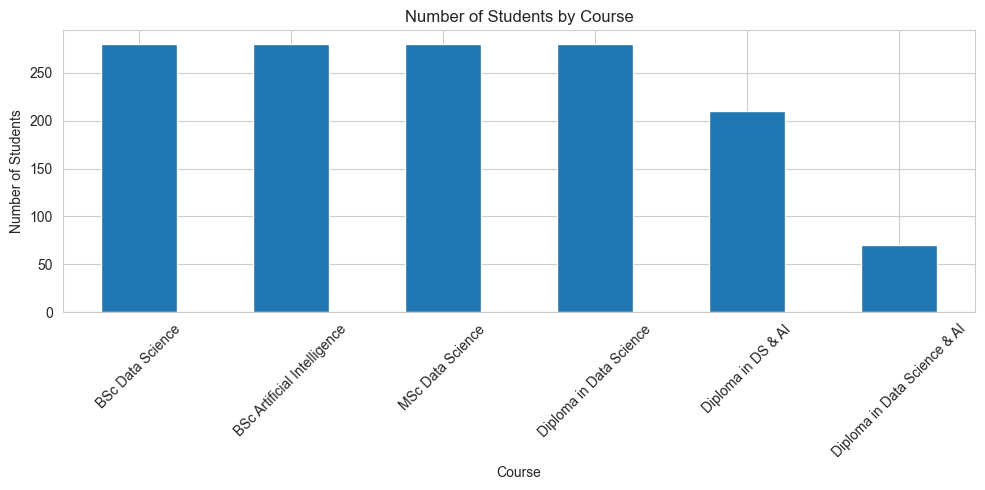

In [13]:
# 12. Chart: Students by course

if "Course" in student_df.columns:
    student_df["Course"].value_counts().plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Number of Students by Course")
    plt.xlabel("Course")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [14]:
# 13. Students by academic year

if "Academic Year" in student_df.columns:
    students_by_year = (
        student_df["Academic Year"]
        .value_counts()
        .sort_index()
    )

    print(students_by_year)
else:
    print("Academic Year column was not found.")


Academic Year
2022-23    350
2023-24    350
2024-25    700
Name: count, dtype: int64


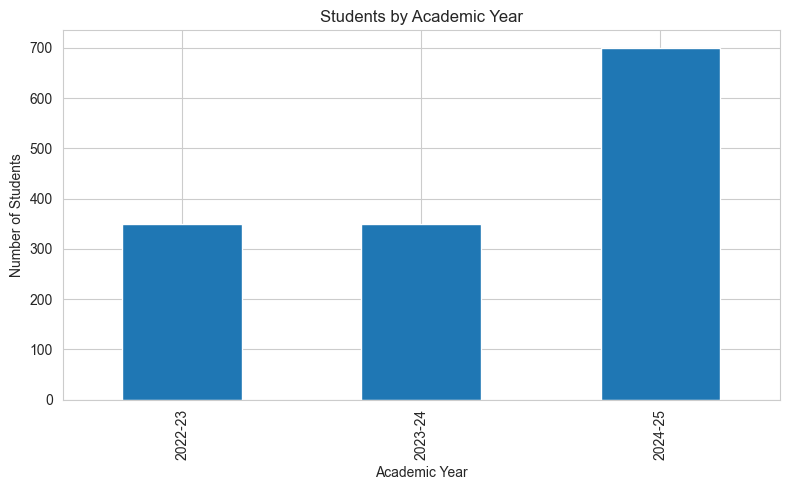

In [15]:
# 14. Chart: Students by academic year

if "Academic Year" in student_df.columns:
    student_df["Academic Year"].value_counts().sort_index().plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Students by Academic Year")
    plt.xlabel("Academic Year")
    plt.ylabel("Number of Students")
    plt.tight_layout()
    plt.show()


Semester
I      448
II     448
III    164
IV     164
V       88
VI      88
Name: count, dtype: int64


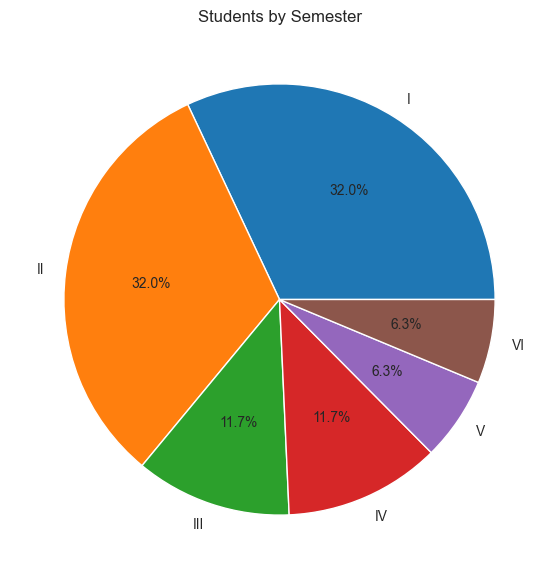

In [16]:
# 15. Students by semester

if "Semester" in student_df.columns:
    semester_count = student_df["Semester"].value_counts()

    print(semester_count)

    semester_count.plot(
        kind="pie",
        autopct="%1.1f%%",
        figsize=(7, 7)
    )

    plt.title("Students by Semester")
    plt.ylabel("")
    plt.show()


Grade Distribution:
Grade
A     494
B+    466
B     212
A+    191
O      21
C      16
Name: count, dtype: int64


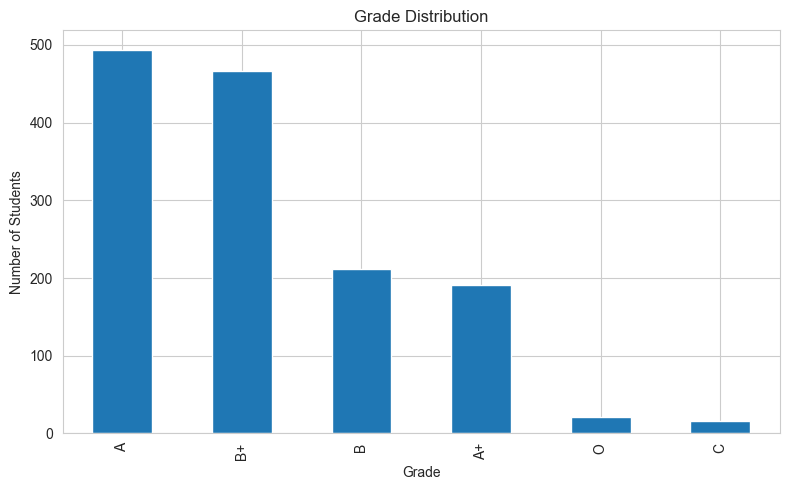

In [17]:
# 16. Grade distribution

if "Grade" in student_df.columns:
    grade_counts = student_df["Grade"].value_counts()

    print("Grade Distribution:")
    print(grade_counts)

    grade_counts.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title("Grade Distribution")
    plt.xlabel("Grade")
    plt.ylabel("Number of Students")
    plt.tight_layout()
    plt.show()


Course
BSc Artificial Intelligence     70.206429
MSc Data Science                70.076786
Diploma in Data Science         70.071071
Diploma in DS & AI              69.734762
BSc Data Science                69.554286
Diploma in Data Science & AI    69.522857
Name: Total Marks, dtype: float64


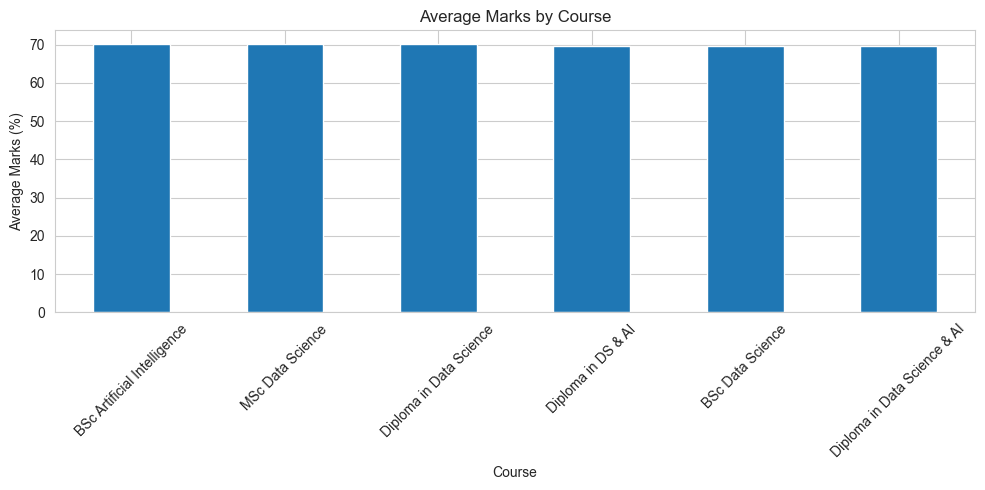

In [18]:
# 17. Average marks by course

if "Course" in student_df.columns and marks_column is not None:
    average_marks_course = (
        student_df.groupby("Course")[marks_column]
        .mean()
        .sort_values(ascending=False)
    )

    print(average_marks_course)

    average_marks_course.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Average Marks by Course")
    plt.xlabel("Course")
    plt.ylabel("Average Marks (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Course
BSc Artificial Intelligence     77.280357
Diploma in Data Science         76.616786
BSc Data Science                76.446786
MSc Data Science                76.081429
Diploma in DS & AI              75.928571
Diploma in Data Science & AI    75.530000
Name: Attendance, dtype: float64


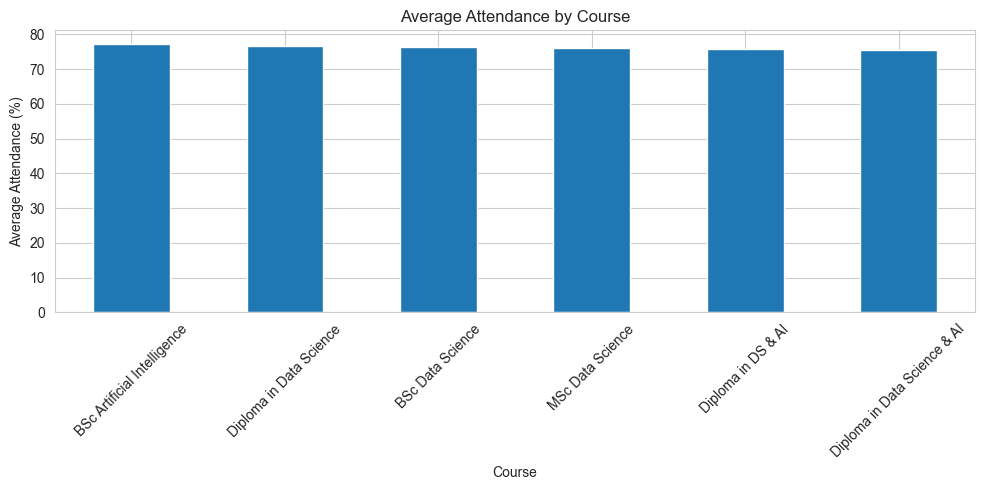

In [19]:
# 18. Average attendance by course

if "Course" in student_df.columns and attendance_column is not None:
    average_attendance_course = (
        student_df.groupby("Course")[attendance_column]
        .mean()
        .sort_values(ascending=False)
    )

    print(average_attendance_course)

    average_attendance_course.plot(
        kind="bar",
        figsize=(10, 5)
    )

    plt.title("Average Attendance by Course")
    plt.xlabel("Course")
    plt.ylabel("Average Attendance (%)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Pass_Fail
Pass    1384
Fail      16
Name: count, dtype: int64


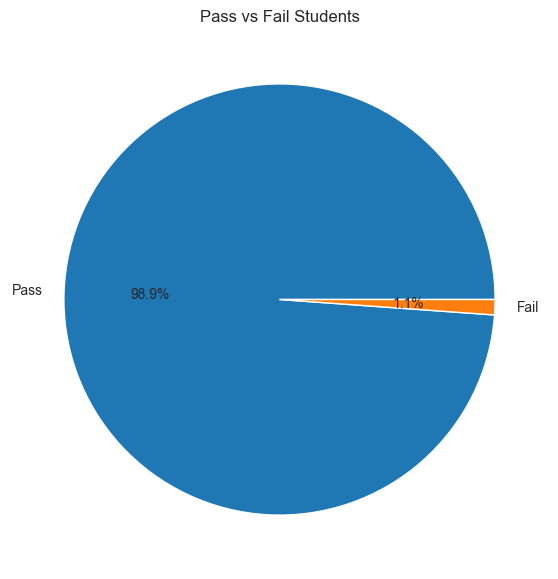

In [20]:
# 19. Pass and Fail analysis

if "Pass_Fail" in student_df.columns:
    pass_fail_count = student_df["Pass_Fail"].value_counts()

    print(pass_fail_count)

    pass_fail_count.plot(
        kind="pie",
        autopct="%1.1f%%",
        figsize=(7, 7)
    )

    plt.title("Pass vs Fail Students")
    plt.ylabel("")
    plt.show()


Normal Attendance    743
Low Attendance       657
Name: count, dtype: int64


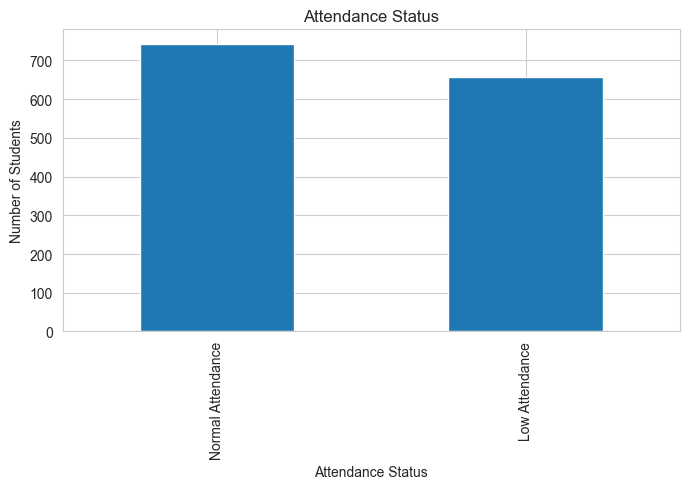

In [21]:
# 20. Attendance analysis

if attendance_column is not None:
    attendance_status = np.where(
        student_df[attendance_column] < 75,
        "Low Attendance",
        "Normal Attendance"
    )

    attendance_count = pd.Series(
        attendance_status
    ).value_counts()

    print(attendance_count)

    attendance_count.plot(
        kind="bar",
        figsize=(7, 5)
    )

    plt.title("Attendance Status")
    plt.xlabel("Attendance Status")
    plt.ylabel("Number of Students")
    plt.tight_layout()
    plt.show()


Performing    734
At-Risk       666
Name: count, dtype: int64


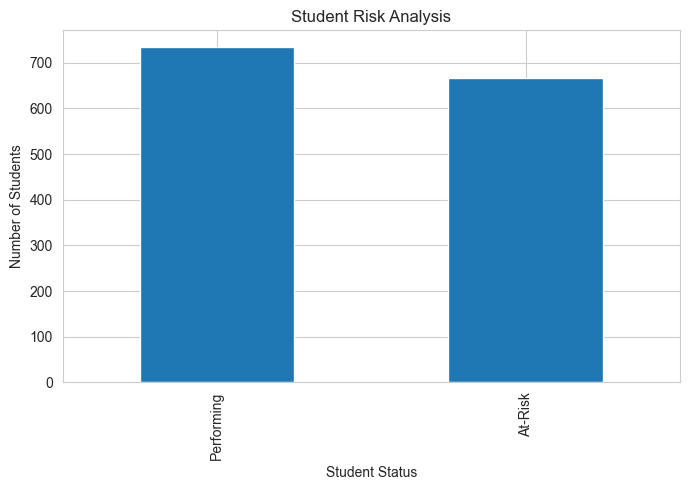

In [22]:
# 21. At-Risk student analysis

if "At_Risk" in student_df.columns:
    risk_status = np.where(
        student_df["At_Risk"] == 1,
        "At-Risk",
        "Performing"
    )

    risk_count = pd.Series(
        risk_status
    ).value_counts()

    print(risk_count)

    risk_count.plot(
        kind="bar",
        figsize=(7, 5)
    )

    plt.title("Student Risk Analysis")
    plt.xlabel("Student Status")
    plt.ylabel("Number of Students")
    plt.tight_layout()
    plt.show()


In [47]:
# 22. Top 10 Students

if "Student Name" in student_df.columns and marks_column is not None:

    # Sort students by marks from highest to lowest
    top_students = (
        student_df
        .sort_values(
            by=marks_column,
            ascending=False
        )
        .head(10)
    )

    # Select columns to display
    columns_to_show = [
        column for column in [
            "Student Name",
            "Course",
            marks_column,
            "Grade"
        ]
        if column in top_students.columns
    ]

    # Display Top 10 Students
    print("Top 10 Performing Students:")
    print("=" * 50)

    display(
        top_students[columns_to_show]
    )

else:
    print("Student Name or Marks column was not found.")

Top 10 Performing Students:


,Student Name,Course,Total Marks,Grade
233,Yashantu Awana,Diploma in Data Science,96.4,O
499,Kaushlendra Singh,BSc Data Science,95.0,O
25,Smita Bagri,BSc Data Science,94.9,O
979,Priya Iyer,MSc Data Science,94.1,O
1083,Akash Mishra,Diploma in Data Science,93.8,O
195,Barun Tiwari,MSc Data Science,93.5,O
789,Abhishek Bhatt,MSc Data Science,93.1,O
142,Harsh Janghera,MSc Data Science,92.0,O
54,Megha Bagri,BSc Data Science,91.7,O
108,Amit Dwivedi,BSc Artificial Intelligence,91.4,O


In [24]:
# 23. Students Needing Academic Improvement

if marks_column is not None:

    # Find students with marks below 50
    weak_students = student_df[
        student_df[marks_column] < 50
    ]

    # Select columns to display
    columns_to_show = [
        "Student Name",
        "Course",
        marks_column
    ]

    # Add attendance if available
    if attendance_column is not None:
        columns_to_show.append(attendance_column)

    # Display the result
    print("Students Needing Academic Improvement:")
    print("=" * 50)

    display(
        weak_students[columns_to_show].head(20)
    )

else:
    print("Marks column was not found.")

Students Needing Academic Improvement:


,Student Name,Course,Total Marks,Attendance
67,Suresh Shukla,BSc Data Science,46.7,87.4
88,Himanshi Rajput,BSc Artificial Intelligence,48.5,66.4
194,Tarun Mathur,MSc Data Science,49.5,84.8
273,Aarush Yadav,Diploma in Data Science,48.0,71.2
336,Shlok Chaudhary,Diploma in Data Science & AI,45.7,87.8
452,Geeta Rai,BSc Data Science,48.8,95.5
463,Aman Patel,BSc Data Science,43.3,77.5
491,Akash Kumar,BSc Data Science,49.5,60.5
566,Nidhi Sharma,BSc Artificial Intelligence,49.3,95.3
584,Ranjeet Oberoi,BSc Artificial Intelligence,49.8,82.6


In [25]:
# 24. Fee analysis

# This section works if fee columns exist in your dataset.

fee_paid_column = next(
    (
        column for column in [
            "Fees Paid ($)",
            "Fees Paid"
        ]
        if column in student_df.columns
    ),
    None
)

fee_due_column = next(
    (
        column for column in [
            "Fees Due ($)",
            "Fees Due"
        ]
        if column in student_df.columns
    ),
    None
)

total_fee_column = next(
    (
        column for column in [
            "Total Fees ($)",
            "Total Fees"
        ]
        if column in student_df.columns
    ),
    None
)

if total_fee_column and fee_paid_column:
    student_df["Calculated_Fees_Due"] = (
        student_df[total_fee_column]
        - student_df[fee_paid_column]
    )

    print("Total Fees:",
          student_df[total_fee_column].sum())

    print("Total Fees Paid:",
          student_df[fee_paid_column].sum())

    print("Total Fees Due:",
          student_df["Calculated_Fees_Due"].sum())
else:
    print("Fee columns were not found.")


Total Fees: 70000000
Total Fees Paid: 23980000
Total Fees Due: 46020000


Fee_Status
Payment Due    1177
Fully Paid      223
Name: count, dtype: int64


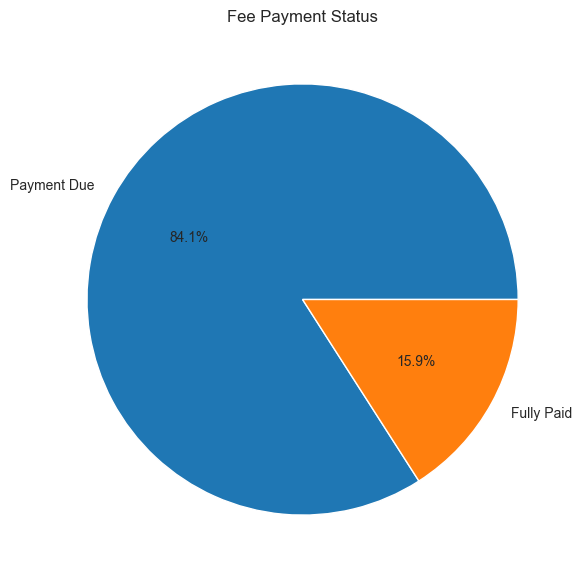

In [26]:
# 25. Fee payment status

if "Calculated_Fees_Due" in student_df.columns:
    student_df["Fee_Status"] = np.where(
        student_df["Calculated_Fees_Due"] <= 0,
        "Fully Paid",
        "Payment Due"
    )

    fee_status_count = student_df[
        "Fee_Status"
    ].value_counts()

    print(fee_status_count)

    fee_status_count.plot(
        kind="pie",
        autopct="%1.1f%%",
        figsize=(7, 7)
    )

    plt.title("Fee Payment Status")
    plt.ylabel("")
    plt.show()


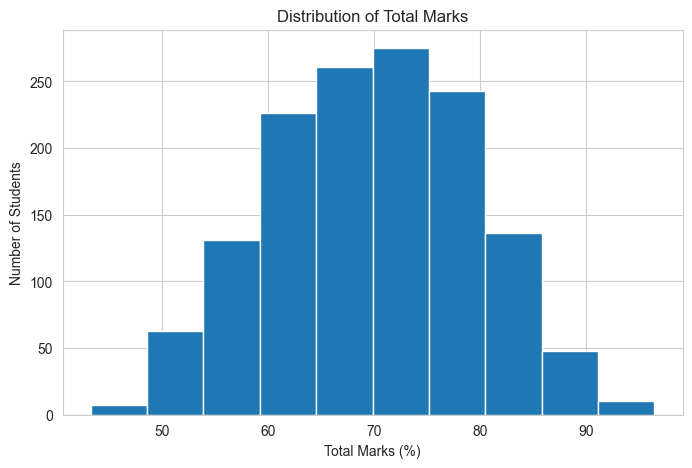

In [27]:
# 26. Marks distribution

if marks_column is not None:
    plt.figure(figsize=(8, 5))

    plt.hist(
        student_df[marks_column].dropna(),
        bins=10
    )

    plt.title("Distribution of Total Marks")
    plt.xlabel("Total Marks (%)")
    plt.ylabel("Number of Students")
    plt.show()


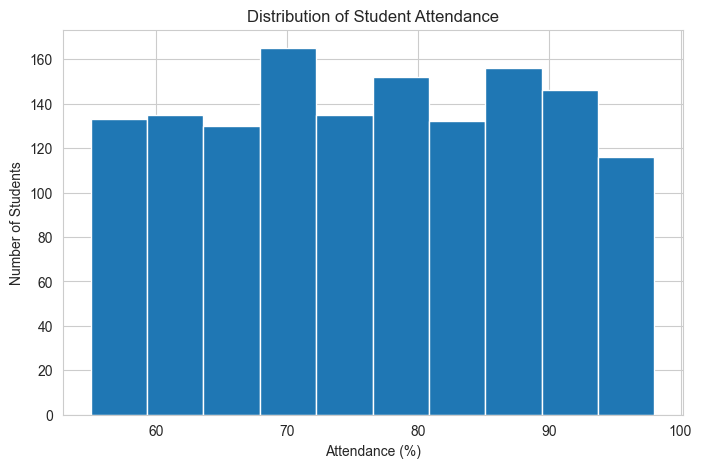

In [28]:
# 27. Attendance distribution

if attendance_column is not None:
    plt.figure(figsize=(8, 5))

    plt.hist(
        student_df[attendance_column].dropna(),
        bins=10
    )

    plt.title("Distribution of Student Attendance")
    plt.xlabel("Attendance (%)")
    plt.ylabel("Number of Students")
    plt.show()


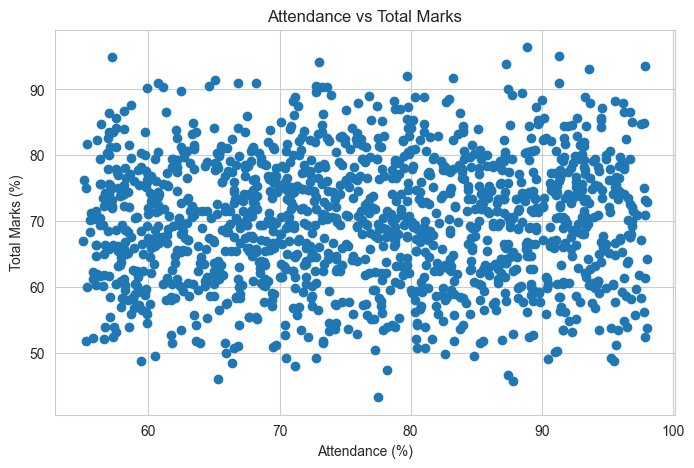

In [29]:
# 28. Attendance vs Marks

if attendance_column is not None and marks_column is not None:
    plt.figure(figsize=(8, 5))

    plt.scatter(
        student_df[attendance_column],
        student_df[marks_column]
    )

    plt.title("Attendance vs Total Marks")
    plt.xlabel("Attendance (%)")
    plt.ylabel("Total Marks (%)")
    plt.show()


In [30]:
# 29. Correlation between attendance and marks

if attendance_column is not None and marks_column is not None:
    correlation = student_df[
        attendance_column
    ].corr(
        student_df[marks_column]
    )

    print(
        "Correlation between Attendance and Marks:",
        round(correlation, 2)
    )

    if correlation > 0:
        print("There is a positive relationship.")
    elif correlation < 0:
        print("There is a negative relationship.")
    else:
        print("There is no clear relationship.")


Correlation between Attendance and Marks: 0.03
There is a positive relationship.


Academic Year
2022-23    69.928571
2023-24    69.563143
2024-25    70.090286
Name: Total Marks, dtype: float64


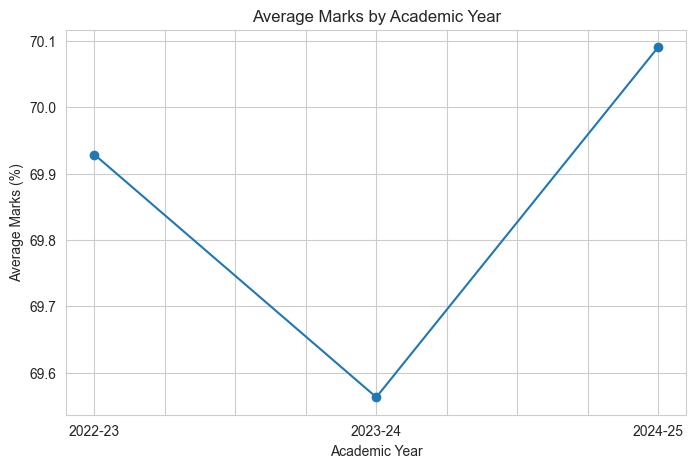

In [31]:
# 30. Average marks by academic year

if "Academic Year" in student_df.columns and marks_column is not None:
    yearly_marks = (
        student_df.groupby("Academic Year")[marks_column]
        .mean()
    )

    print(yearly_marks)

    yearly_marks.plot(
        kind="line",
        marker="o",
        figsize=(8, 5)
    )

    plt.title("Average Marks by Academic Year")
    plt.xlabel("Academic Year")
    plt.ylabel("Average Marks (%)")
    plt.show()


Academic Year
2022-23    76.719714
2023-24    75.765143
2024-25    76.659286
Name: Attendance, dtype: float64


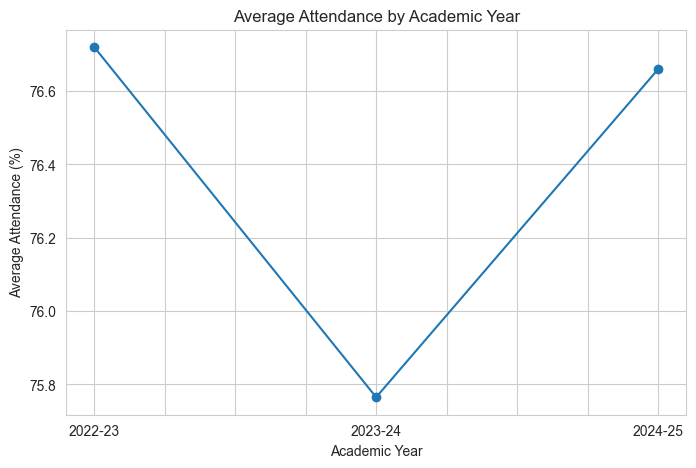

In [32]:
# 31. Average attendance by academic year

if "Academic Year" in student_df.columns and attendance_column is not None:
    yearly_attendance = (
        student_df.groupby("Academic Year")[attendance_column]
        .mean()
    )

    print(yearly_attendance)

    yearly_attendance.plot(
        kind="line",
        marker="o",
        figsize=(8, 5)
    )

    plt.title("Average Attendance by Academic Year")
    plt.xlabel("Academic Year")
    plt.ylabel("Average Attendance (%)")
    plt.show()


In [33]:
print(student_df.columns.tolist())

['Student Name', 'Course', 'Academic Year', 'Semester', 'Section', 'Roll No', 'Enrollment No', 'Mentor', 'Attendance', 'Fees Paid', 'Fees Due', 'Total Fees', 'Mid Term', 'End Term', 'Assignment', 'Practical', 'Total Marks', 'Grade', 'Class Performance', 'Remarks', 'Pass_Fail', 'Low_Attendance', 'At_Risk', 'Calculated_Fees_Due', 'Fee_Status']


In [34]:
# 32. Student Performance Summary

# Check available columns
print("Available columns:")
print(student_df.columns.tolist())

# Check if Course column exists
if "Course" in student_df.columns:

    # Create summary
    performance_summary = (
        student_df
        .groupby("Course")
        .agg(
            Total_Students=("Student Name", "count"),
            Average_Marks=(marks_column, "mean"),
            Average_Attendance=(attendance_column, "mean")
        )
        .round(2)
    )

    # Display summary
    print("\nStudent Performance Summary:")
    display(performance_summary)

else:
    print(
        "Error: 'Course' column was not found."
    )

Available columns:
['Student Name', 'Course', 'Academic Year', 'Semester', 'Section', 'Roll No', 'Enrollment No', 'Mentor', 'Attendance', 'Fees Paid', 'Fees Due', 'Total Fees', 'Mid Term', 'End Term', 'Assignment', 'Practical', 'Total Marks', 'Grade', 'Class Performance', 'Remarks', 'Pass_Fail', 'Low_Attendance', 'At_Risk', 'Calculated_Fees_Due', 'Fee_Status']

Student Performance Summary:


,Total_Students,Average_Marks,Average_Attendance
Course,,,
BSc Artificial Intelligence,280,70.21,77.28
BSc Data Science,280,69.55,76.45
Diploma in DS & AI,210,69.73,75.93
Diploma in Data Science,280,70.07,76.62
Diploma in Data Science & AI,70,69.52,75.53
MSc Data Science,280,70.08,76.08


In [35]:
# 33. Best performing course

if "performance_summary" in locals() and "Average_Marks" in performance_summary.columns:
    best_course = performance_summary[
        "Average_Marks"
    ].idxmax()

    best_marks = performance_summary[
        "Average_Marks"
    ].max()

    print("Best Performing Course:", best_course)
    print("Average Marks:", round(best_marks, 2), "%")


Best Performing Course: BSc Artificial Intelligence
Average Marks: 70.21 %


In [36]:
# 34. Course with lowest attendance

if "performance_summary" in locals() and "Average_Attendance" in performance_summary.columns:
    lowest_attendance_course = performance_summary[
        "Average_Attendance"
    ].idxmin()

    lowest_attendance = performance_summary[
        "Average_Attendance"
    ].min()

    print(
        "Course with Lowest Attendance:",
        lowest_attendance_course
    )

    print(
        "Average Attendance:",
        round(lowest_attendance, 2),
        "%"
    )


Course with Lowest Attendance: Diploma in Data Science & AI
Average Attendance: 75.53 %


In [37]:
# 35. Final Project Summary

print("=" * 50)
print("STUDENT ANALYTICS SUMMARY")
print("=" * 50)

# Total Students
if "Student Name" in student_df.columns:
    print(
        "Total Students:",
        student_df["Student Name"].nunique()
    )

# Total Records
print(
    "Total Records:",
    len(student_df)
)

# Total Courses
if "Course" in student_df.columns:
    print(
        "Total Courses:",
        student_df["Course"].nunique()
    )

# Average Attendance
if attendance_column is not None:
    print(
        "Average Attendance:",
        round(
            student_df[attendance_column].mean(),
            2
        ),
        "%"
    )

# Average Marks
if marks_column is not None:
    print(
        "Average Marks:",
        round(
            student_df[marks_column].mean(),
            2
        ),
        "%"
    )

# Pass Rate
if "Pass_Fail" in student_df.columns:
    pass_rate = (
        student_df["Pass_Fail"]
        .eq("Pass")
        .mean() * 100
    )

    print(
        "Pass Rate:",
        round(
            pass_rate,
            2
        ),
        "%"
    )

# At-Risk Students
if "At_Risk" in student_df.columns:
    print(
        "At-Risk Records:",
        student_df["At_Risk"].sum()
    )

# ------------------------------------------
# Top Performing Student
# ------------------------------------------

if (
    "Student Name" in student_df.columns
    and marks_column is not None
):

    # Find student with highest marks
    top_student = student_df.loc[
        student_df[marks_column].idxmax()
    ]

    print("\n" + "=" * 50)
    print("TOP PERFORMING STUDENT")
    print("=" * 50)

    print(
        "Student Name:",
        top_student["Student Name"]
    )

    print(
        "Marks:",
        round(
            top_student[marks_column],
            2
        )
    )

    # Show course if available
    if "Course" in student_df.columns:
        print(
            "Course:",
            top_student["Course"]
        )

    # Show attendance if available
    if attendance_column is not None:
        print(
            "Attendance:",
            round(
                top_student[attendance_column],
                2
            ),
            "%"
        )

print("=" * 50)

STUDENT ANALYTICS SUMMARY
Total Students: 344
Total Records: 1400
Total Courses: 6
Average Attendance: 76.45 %
Average Marks: 69.92 %
Pass Rate: 98.86 %
At-Risk Records: 666

TOP PERFORMING STUDENT
Student Name: Yashantu Awana
Marks: 96.4
Course: Diploma in Data Science
Attendance: 88.9 %


In [38]:
# 38. Prepare machine learning data

# Find available feature columns
possible_features = [
    "Attendance (%)",
    "Attendance",
    "Mid-Term Marks",
    "Mid Term",
    "End-Term Marks",
    "End Term",
    "Assignment Marks",
    "Assignment",
    "Practical Marks",
    "Practical"
]

features = [
    column for column in possible_features
    if column in student_df.columns
]

print("Features used:")
print(features)

if "At_Risk" in student_df.columns and len(features) >= 2:
    ml_data = student_df[
        features + ["At_Risk"]
    ].dropna()

    X = ml_data[features]
    y = ml_data["At_Risk"]

    print("ML dataset shape:", ml_data.shape)
else:
    print("Not enough data for the ML model.")


Features used:
['Attendance', 'Mid Term', 'End Term', 'Assignment', 'Practical']
ML dataset shape: (1400, 6)


In [39]:
# 39. Split data into training and testing sets

if "X" in locals() and len(X) > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    print("Training data:", X_train.shape)
    print("Testing data:", X_test.shape)

Training data: (1120, 5)
Testing data: (280, 5)


In [48]:
# 41. Make Predictions Using 3 ML Models

if "fitted_models" in globals() and fitted_models:

    print("=" * 50)
    print("PREDICTIONS FROM 3 ML MODELS")
    print("=" * 50)

    for name, (trained_model, _) in fitted_models.items():

        # Make predictions using the correct test data
        predictions = trained_model.predict(
            x_test
        )

        print("\nModel:", name)

        print(
            "First 10 Predictions:"
        )

        print(
            predictions[:10]
        )

else:

    print(
        "No trained models found."
    )

PREDICTIONS FROM 3 ML MODELS

Model: Random Forest
First 10 Predictions:
[0 1 0 0 1 0 1 0 0 1]

Model: Gradient Boosting
First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

Model: Logistic Regression
First 10 Predictions:
[0 0 0 0 0 0 1 0 0 1]


In [49]:
# 42. Check model accuracy

if "predictions" in locals():
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    print(
        "Model Accuracy:",
        round(accuracy * 100, 2),
        "%"
    )


Model Accuracy: 49.71 %


In [50]:
# 42. Check Accuracy of 3 ML Models

if "fitted_models" in globals() and fitted_models:

    print("=" * 50)
    print("MODEL ACCURACY")
    print("=" * 50)

    accuracy_results = []

    for name, (trained_model, _) in fitted_models.items():

        # Make predictions
        predictions = trained_model.predict(
            x_test
        )

        # Calculate accuracy
        accuracy = accuracy_score(
            y_test,
            predictions
        )

        # Save result
        accuracy_results.append({
            "Model": name,
            "Accuracy (%)": round(
                accuracy * 100,
                2
            )
        })

        # Display accuracy
        print(
            name,
            "Accuracy:",
            round(
                accuracy * 100,
                2
            ),
            "%"
        )

    # Create accuracy table
    accuracy_results = pd.DataFrame(
        accuracy_results
    )

    # Sort by accuracy
    accuracy_results = (
        accuracy_results
        .sort_values(
            "Accuracy (%)",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print("\n" + "=" * 50)
    print("MODEL ACCURACY COMPARISON")
    print("=" * 50)

    display(
        accuracy_results
    )

else:

    print(
        "No trained models found."
    )

MODEL ACCURACY
Random Forest Accuracy: 50.57 %
Gradient Boosting Accuracy: 52.86 %
Logistic Regression Accuracy: 49.71 %

MODEL ACCURACY COMPARISON


,Model,Accuracy (%)
0,Gradient Boosting,52.86
1,Random Forest,50.57
2,Logistic Regression,49.71


## Machine Learning — At-Risk Prediction

This section trains and compares **3 Machine Learning models**:

1. **Random Forest**
2. **Gradient Boosting**
3. **Logistic Regression**

The models are compared using **Accuracy**. 


In [51]:
# 16. ML — At-Risk Prediction
# Compare 3 Machine Learning Models using Accuracy only

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

TARGET = "At_Risk"

if TARGET not in student_df.columns:
    print("ML skipped: At_Risk target is unavailable.")

else:
    # Select features
    numeric_features = [
        c for c in [
            "Attendance (%)",
            "Mid-Term Marks",
            "End-Term Marks",
            "Assignment Marks",
            "Practical Marks"
        ]
        if c in student_df.columns
    ]

    categorical_features = [
        c for c in ["Course"]
        if c in student_df.columns
    ]

    features = numeric_features + categorical_features

    # Prepare ML data
    ml_data = student_df[
        features + [TARGET]
    ].copy()

    ml_data[TARGET] = pd.to_numeric(
        ml_data[TARGET],
        errors="coerce"
    )

    ml_data = ml_data.dropna(
        subset=[TARGET]
    )

    ml_data = ml_data[
        ml_data[TARGET].isin([0, 1])
    ]

    if len(features) == 0:
        print("ML skipped: no usable features.")

    elif (
        ml_data[TARGET].nunique() < 2
        or len(ml_data) < 10
    ):
        print(
            "ML skipped: not enough data "
            "or class diversity."
        )

    else:
        # Input and target
        X = ml_data[features]
        y = ml_data[TARGET].astype(int)

        # Preprocessing
        preprocessor = ColumnTransformer([
            (
                "num",
                SimpleImputer(
                    strategy="median"
                ),
                numeric_features
            ),
            (
                "cat",
                Pipeline([
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        )
                    ),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        )
                    )
                ]),
                categorical_features
            )
        ])

        # ==========================================
        # CREATE 3 MACHINE LEARNING MODELS
        # ==========================================

        models = {
            "Random Forest": RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced"
            ),

            "Gradient Boosting": GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            ),

            "Logistic Regression": Pipeline([
                (
                    "scale",
                    StandardScaler(
                        with_mean=False
                    )
                ),
                (
                    "model",
                    LogisticRegression(
                        max_iter=1000,
                        class_weight="balanced",
                        random_state=42
                    )
                )
            ])
        }

        # Split data
        x_train, x_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=42,
            stratify=y
        )

        # Store results
        model_results = []
        fitted_models = {}

        # ==========================================
        # TRAIN AND TEST ALL 3 MODELS
        # ==========================================

        for name, model in models.items():

            print("\n" + "=" * 60)
            print("MODEL:", name)
            print("=" * 60)

            # Create pipeline
            pipe = Pipeline([
                (
                    "preprocess",
                    preprocessor
                ),
                (
                    "model",
                    model
                )
            ])

            # Train model
            pipe.fit(
                x_train,
                y_train
            )

            # Make predictions
            pred = pipe.predict(
                x_test
            )

            # Calculate accuracy
            accuracy = accuracy_score(
                y_test,
                pred
            )

            # Save result
            model_results.append({
                "Model": name,
                "Accuracy (%)": round(
                    accuracy * 100,
                    2
                )
            })

            # Save trained model
            fitted_models[name] = (
                pipe,
                pred
            )

            # Print accuracy
            print(
                "Accuracy:",
                round(
                    accuracy * 100,
                    2
                ),
                "%"
            )

            # Print classification report
            print("\nClassification Report:")

            print(
                classification_report(
                    y_test,
                    pred,
                    target_names=[
                        "Performing",
                        "At-Risk"
                    ],
                    zero_division=0
                )
            )

        # ==========================================
        # COMPARE THE 3 MODELS
        # ==========================================

        model_results = pd.DataFrame(
            model_results
        )

        model_results = (
            model_results
            .sort_values(
                "Accuracy (%)",
                ascending=False
            )
            .reset_index(
                drop=True
            )
        )

        print("\n" + "=" * 60)
        print("3 MODEL COMPARISON")
        print("=" * 60)

        display(
            model_results
        )

        # ==========================================
        # FIND THE BEST MODEL
        # ==========================================

        best_name = (
            model_results
            .iloc[0]["Model"]
        )

        best_accuracy = (
            model_results
            .iloc[0]["Accuracy (%)"]
        )

        print("\n" + "=" * 60)
        print("BEST MODEL")
        print("=" * 60)

        print(
            "Best Model:",
            best_name
        )

        print(
            "Best Accuracy:",
            best_accuracy,
            "%"
        )



MODEL: Random Forest
Accuracy: 50.57 %

Classification Report:
              precision    recall  f1-score   support

  Performing       0.54      0.41      0.47       184
     At-Risk       0.48      0.61      0.54       166

    accuracy                           0.51       350
   macro avg       0.51      0.51      0.50       350
weighted avg       0.51      0.51      0.50       350


MODEL: Gradient Boosting
Accuracy: 52.86 %

Classification Report:
              precision    recall  f1-score   support

  Performing       0.53      0.96      0.68       184
     At-Risk       0.53      0.05      0.09       166

    accuracy                           0.53       350
   macro avg       0.53      0.51      0.39       350
weighted avg       0.53      0.53      0.40       350


MODEL: Logistic Regression
Accuracy: 49.71 %

Classification Report:
              precision    recall  f1-score   support

  Performing       0.52      0.60      0.56       184
     At-Risk       0.46      0.39  

,Model,Accuracy (%)
0,Gradient Boosting,52.86
1,Random Forest,50.57
2,Logistic Regression,49.71



BEST MODEL
Best Model: Gradient Boosting
Best Accuracy: 52.86 %


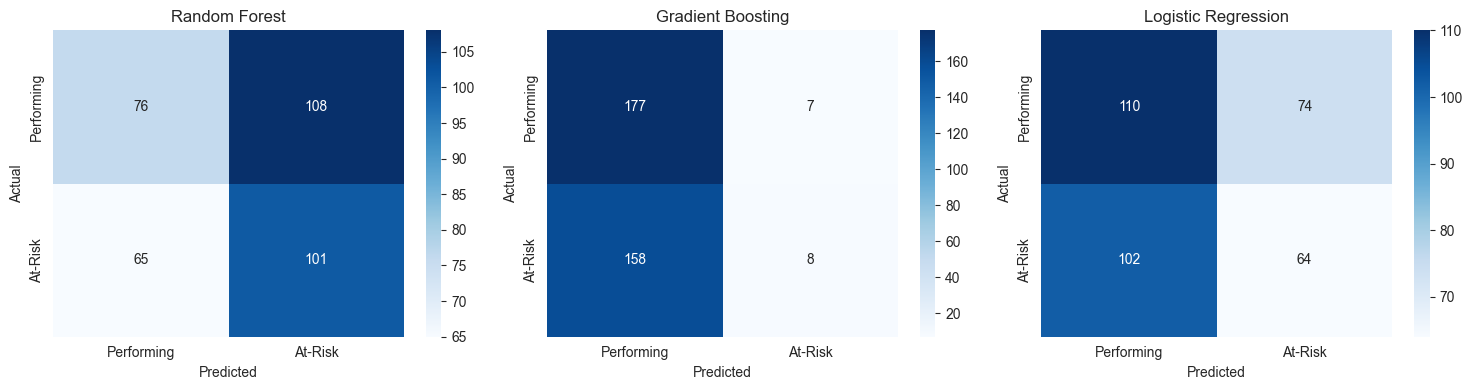

In [52]:
# Confusion Matrix for the 3 ML Models

if "fitted_models" in globals() and fitted_models:

    fig, axes = plt.subplots(
        1,
        len(fitted_models),
        figsize=(5 * len(fitted_models), 4)
    )

    axes = np.atleast_1d(axes)

    for ax, (name, (_, pred)) in zip(
        axes,
        fitted_models.items()
    ):

        cm = confusion_matrix(
            y_test,
            pred,
            labels=[0, 1]
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[
                "Performing",
                "At-Risk"
            ],
            yticklabels=[
                "Performing",
                "At-Risk"
            ],
            ax=ax
        )

        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

else:
    print("No trained ML models are available.")


In [53]:
from pathlib import Path

# Excel file location
FILE_PATH = Path(
    r"C:\Users\YASHANTU AWANA\OneDrive\Desktop\Major\Data.xlsx"
)

print("File path:", FILE_PATH)

File path: C:\Users\YASHANTU AWANA\OneDrive\Desktop\Major\Data.xlsx


In [54]:
# Export cleaned data and ML predictions

OUTPUT_DIR = FILE_PATH.parent / "student_analytics_outputs"

OUTPUT_DIR.mkdir(
    exist_ok=True
)

# Save cleaned data
student_df.to_csv(
    OUTPUT_DIR / "cleaned_student_data.csv",
    index=False,
    encoding="utf-8-sig"
)

# Save predictions from the best model
if "fitted_models" in globals() and fitted_models:

    best_name = model_results.iloc[0]["Model"]

    best_pipe = fitted_models[
        best_name
    ][0]

    student_df[
        "ML_Predicted_AtRisk"
    ] = np.nan

    valid_rows = ml_data.index

    student_df.loc[
        valid_rows,
        "ML_Predicted_AtRisk"
    ] = best_pipe.predict(
        student_df.loc[
            valid_rows,
            features
        ]
    )

    student_df.to_csv(
        OUTPUT_DIR / "student_predictions.csv",
        index=False,
        encoding="utf-8-sig"
    )

    model_results.to_csv(
        OUTPUT_DIR / "model_comparison.csv",
        index=False
    )

    print(
        "Best Model:",
        best_name
    )

    print(
        "Best Accuracy:",
        model_results.iloc[0]["Accuracy (%)"],
        "%"
    )

else:
    print(
        "No trained ML models are available."
    )

print(
    "Outputs saved to:",
    OUTPUT_DIR
)


Best Model: Gradient Boosting
Best Accuracy: 52.86 %
Outputs saved to: C:\Users\YASHANTU AWANA\OneDrive\Desktop\Major\student_analytics_outputs


# Project Completed 🎉


